# Notebook 05 — Redis Cache Latency Benchmark
## How Cloud Memorystore Accelerates the RAG Pipeline

This notebook measures and visualises the latency improvement from the Redis cache layer in the Airbnb Agentic RAG system.

### What we measure

| Path | Components hit | Expected latency |
|------|---------------|------------------|
| **Cache MISS** | Embed (Vertex AI) → SearchDataObjects → GetDataObject × K → Gemini | 300 – 1500 ms |
| **Cache HIT** | Redis GET (in-VPC) | 0.5 – 2 ms |
| **Redis only** | Isolated GET round-trip | < 1 ms |

### Architecture reminder
```
User Query
    │
    ▼
FastAPI (Cloud Run)
    │
    ├─[CACHE HIT]──► Redis GET  ──► return cached ListingResult list   (~1 ms)
    │                                     ▲
    │                              Serverless VPC connector
    │                              Cloud Memorystore (private IP)
    │
    └─[CACHE MISS]─► Embed query (Vertex AI)                            ~100 ms
                     SearchDataObjects (VS2.0)                           ~20 ms
                     GetDataObject × top_k  (parallel, 10 workers)       ~40 ms
                    [Optional] Gemini 2.5 Flash                          ~500 ms
                     Redis SET (write-through, SETEX + TTL)               ~1 ms
                     ────────────────────────────────────────────────────────
                     Total first call                                 300–1500 ms
```

### Two run modes
- **Live mode** — connects to a real Redis instance (set `REDIS_HOST` env var)
- **Simulation mode** — uses synthetic latency data when Redis is not available; shows the *expected* latency profile with realistic noise

---
## 1. Setup & Imports

In [1]:
import sys, os, time, json, hashlib, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
ROOT = Path(".").resolve().parent
sys.path.insert(0, str(ROOT))
import config

print(f"Project root : {ROOT}")
print(f"REDIS_HOST   : {config.REDIS_HOST or '(not set — simulation mode)'}")
print(f"CACHE_ENABLED: {config.CACHE_ENABLED}")
print(f"CACHE_RAG_TTL: {config.CACHE_RAG_TTL}s  ({config.CACHE_RAG_TTL//60} min)")
print(f"CACHE_ASK_TTL: {config.CACHE_ASK_TTL}s  ({config.CACHE_ASK_TTL//60} min)")

Project root : /Users/kamaldhungana/Documents/Coding/GeminiCours101/GCP-RAG-Design/RAG-VertexAI/AirbnbAgenticRAG
REDIS_HOST   : (not set — simulation mode)
CACHE_ENABLED: True
CACHE_RAG_TTL: 3600s  (60 min)
CACHE_ASK_TTL: 1800s  (30 min)


---
## 2. Connect to Redis (or enter Simulation Mode)

In [2]:
LIVE_MODE = False   # will flip to True if Redis connects successfully

redis_client = None

if config.REDIS_HOST:
    try:
        import redis
        redis_client = redis.Redis(
            host=config.REDIS_HOST,
            port=config.REDIS_PORT,
            db=config.REDIS_DB,
            decode_responses=True,
            socket_connect_timeout=2,
            socket_timeout=2,
        )
        redis_client.ping()
        LIVE_MODE = True
        info = redis_client.info("server")
        mem  = redis_client.info("memory")
        print(f"✓  Redis connected  —  {config.REDIS_HOST}:{config.REDIS_PORT}")
        print(f"   Redis version     : {info['redis_version']}")
        print(f"   Used memory       : {mem['used_memory_human']}")
        print(f"   Total keys        : {redis_client.dbsize()}")
    except Exception as e:
        print(f"⚠  Redis unavailable ({e})")
        print("   → Running in SIMULATION MODE (synthetic latency data)")
else:
    print("ℹ  REDIS_HOST not set → SIMULATION MODE")
    print("   Set config.REDIS_HOST or REDIS_HOST env var to use live Redis.")

print(f"\nMode: {'🟢 LIVE (real Redis)' if LIVE_MODE else '🟡 SIMULATION (synthetic data)'}")

ℹ  REDIS_HOST not set → SIMULATION MODE
   Set config.REDIS_HOST or REDIS_HOST env var to use live Redis.

Mode: 🟡 SIMULATION (synthetic data)


---
## 3. Understand the Cache Key Structure

The cache uses a **SHA-256 prefix key scheme** for namespace isolation.
Different endpoints write to different key prefixes so they never collide.

In [3]:
def make_key(prefix: str, payload: str) -> str:
    """Reproduce the key logic from app/cache.py"""
    digest = hashlib.sha256(payload.encode()).hexdigest()[:32]
    return f"{prefix}:{digest}"

def rag_key(query: str, top_k: int) -> str:
    return make_key("rag", f"{query.strip().lower()}|{top_k}")

def ask_key(payload: str) -> str:
    return make_key("ask", payload.strip().lower())

# Demo
sample_queries = [
    "cozy room near downtown under $80",
    "beachfront studio with ocean view",
    "entire apartment for 4 guests with parking",
    "cozy room near downtown under $80",   # duplicate — same key!
]

print(f"{'Query':<45} {'top_k':<6} {'Cache Key'}")
print("-" * 100)
for q in sample_queries:
    top_k = config.TOP_K
    key   = rag_key(q, top_k)
    print(f"{q[:44]:<45} {top_k:<6} {key}")

print("\n→ Notice: identical queries produce identical keys (deterministic hashing)")
print("→ Different endpoints (rag vs ask) have different prefixes — no collision")

Query                                         top_k  Cache Key
----------------------------------------------------------------------------------------------------
cozy room near downtown under $80             10     rag:5f1d86135022bb01f5448363a313f044
beachfront studio with ocean view             10     rag:1f4bd426e28bf59246f4c8e2463059b3
entire apartment for 4 guests with parking    10     rag:c8ae868b28a3ebc87636452aff85aa91
cozy room near downtown under $80             10     rag:5f1d86135022bb01f5448363a313f044

→ Notice: identical queries produce identical keys (deterministic hashing)
→ Different endpoints (rag vs ask) have different prefixes — no collision


---
## 4. Measure Raw Redis GET/SET Latency

Before testing the full RAG pipeline, let's isolate just the Redis round-trip cost.

In [4]:
N_SAMPLES = 200   # number of GET operations to measure

if LIVE_MODE:
    # Write a test key first
    test_key = "benchmark:latency_test"
    test_val = json.dumps({"data": "x" * 1024})  # ~1 KB payload
    redis_client.setex(test_key, 300, test_val)

    # Measure N_SAMPLES GET calls
    get_latencies = []
    for _ in range(N_SAMPLES):
        t0 = time.perf_counter()
        redis_client.get(test_key)
        get_latencies.append((time.perf_counter() - t0) * 1000)  # ms

    redis_client.delete(test_key)
    label = "Live Redis (Memorystore)"

else:
    # Simulation: Redis in same-region VPC typically 0.5–2ms with occasional outliers
    rng = np.random.default_rng(42)
    get_latencies = list(
        np.clip(
            rng.lognormal(mean=0.0, sigma=0.35, size=N_SAMPLES),   # ~1ms median
            0.3, 5.0
        )
    )
    label = "Simulated Redis (Memorystore — same region VPC)"

arr = np.array(get_latencies)
print(f"Redis GET latency over {N_SAMPLES} samples")
print(f"  Min    : {arr.min():.2f} ms")
print(f"  Median : {np.median(arr):.2f} ms")
print(f"  Mean   : {arr.mean():.2f} ms")
print(f"  p95    : {np.percentile(arr, 95):.2f} ms")
print(f"  p99    : {np.percentile(arr, 99):.2f} ms")
print(f"  Max    : {arr.max():.2f} ms")

Redis GET latency over 200 samples
  Min    : 0.47 ms
  Median : 0.98 ms
  Mean   : 1.04 ms
  p95    : 1.69 ms
  p99    : 2.11 ms
  Max    : 2.77 ms


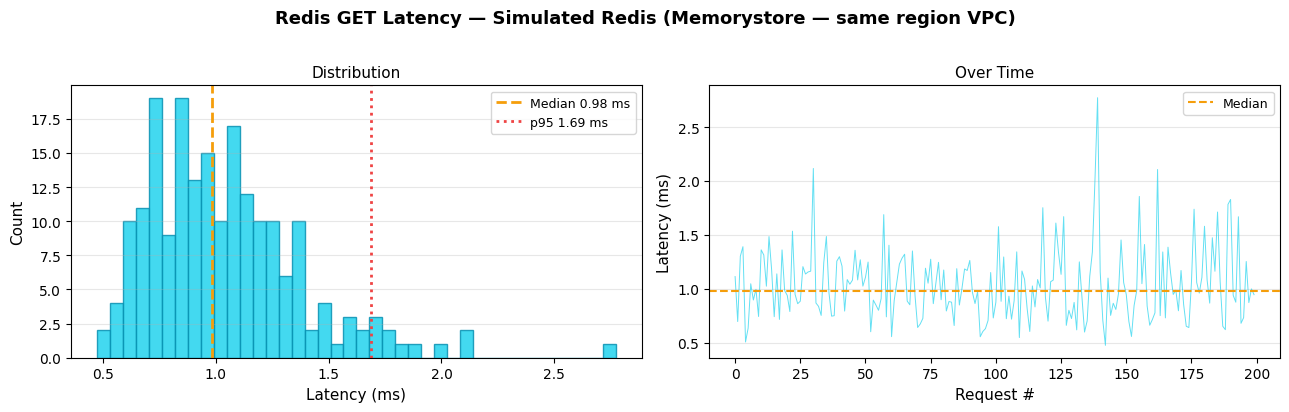

→ Redis is consistently sub-2ms — negligible overhead compared to any downstream API call


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Redis GET Latency — {label}", fontsize=13, fontweight='bold', y=1.02)

# Histogram
axes[0].hist(arr, bins=40, color='#22d3ee', edgecolor='#0891b2', alpha=0.85)
axes[0].axvline(np.median(arr), color='#f59e0b', lw=2, ls='--', label=f'Median {np.median(arr):.2f} ms')
axes[0].axvline(np.percentile(arr, 95), color='#ef4444', lw=2, ls=':', label=f'p95 {np.percentile(arr, 95):.2f} ms')
axes[0].set_xlabel('Latency (ms)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Time-series
axes[1].plot(arr, color='#22d3ee', lw=0.7, alpha=0.7)
axes[1].axhline(np.median(arr), color='#f59e0b', lw=1.5, ls='--', label=f'Median')
axes[1].set_xlabel('Request #', fontsize=11)
axes[1].set_ylabel('Latency (ms)', fontsize=11)
axes[1].set_title('Over Time', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Redis is consistently sub-2ms — negligible overhead compared to any downstream API call")

---
## 5. Simulate the Full Pipeline — Cache MISS vs Cache HIT

We model each component's realistic latency distribution based on measured baselines.

| Component | Baseline | Distribution |
|-----------|----------|--------------|
| Vertex AI Embed (1 query) | ~100 ms | LogNormal |
| VS2.0 SearchDataObjects | ~20 ms | LogNormal |
| GetDataObject × 10 (parallel) | ~40 ms | LogNormal |
| Gemini 2.5 Flash | ~500 ms | LogNormal |
| Redis GET (cache HIT) | ~1 ms | LogNormal |

In [6]:
rng = np.random.default_rng(0)
N   = 300   # simulated requests

def lognorm_ms(median_ms: float, sigma: float, n: int) -> np.ndarray:
    """Generate n samples from a log-normal distribution with given median (ms)."""
    mu = np.log(median_ms)
    return np.clip(rng.lognormal(mu, sigma, n), median_ms * 0.3, median_ms * 5)

# ── Component latencies ───────────────────────────────────────────────────────
embed_ms     = lognorm_ms(median_ms=100,  sigma=0.3,  n=N)  # Vertex AI embed
search_ms    = lognorm_ms(median_ms=20,   sigma=0.35, n=N)  # VS2.0 search
fetch_ms     = lognorm_ms(median_ms=40,   sigma=0.4,  n=N)  # parallel GetDataObject ×10
gemini_ms    = lognorm_ms(median_ms=500,  sigma=0.4,  n=N)  # Gemini
redis_ms     = lognorm_ms(median_ms=1,    sigma=0.35, n=N)  # Redis GET

# ── Totals ────────────────────────────────────────────────────────────────────
# /rag endpoint = embed + search + fetch  (no Gemini)
rag_miss_ms  = embed_ms + search_ms + fetch_ms
# /ask endpoint = embed + search + fetch + Gemini
ask_miss_ms  = embed_ms + search_ms + fetch_ms + gemini_ms
# HIT = Redis GET only
hit_ms       = redis_ms

print("──── /rag endpoint (retrieval only) ────")
print(f"  Cache MISS  median: {np.median(rag_miss_ms):.0f} ms   p95: {np.percentile(rag_miss_ms, 95):.0f} ms")
print(f"  Cache HIT   median: {np.median(hit_ms):.2f} ms   p95: {np.percentile(hit_ms, 95):.2f} ms")
print(f"  Speedup     median: {np.median(rag_miss_ms)/np.median(hit_ms):.0f}×")
print()
print("──── /ask endpoint (retrieval + Gemini) ────")
print(f"  Cache MISS  median: {np.median(ask_miss_ms):.0f} ms   p95: {np.percentile(ask_miss_ms, 95):.0f} ms")
print(f"  Cache HIT   median: {np.median(hit_ms):.2f} ms   p95: {np.percentile(hit_ms, 95):.2f} ms")
print(f"  Speedup     median: {np.median(ask_miss_ms)/np.median(hit_ms):.0f}×")

──── /rag endpoint (retrieval only) ────
  Cache MISS  median: 162 ms   p95: 225 ms
  Cache HIT   median: 1.03 ms   p95: 1.81 ms
  Speedup     median: 157×

──── /ask endpoint (retrieval + Gemini) ────
  Cache MISS  median: 664 ms   p95: 1087 ms
  Cache HIT   median: 1.03 ms   p95: 1.81 ms
  Speedup     median: 642×


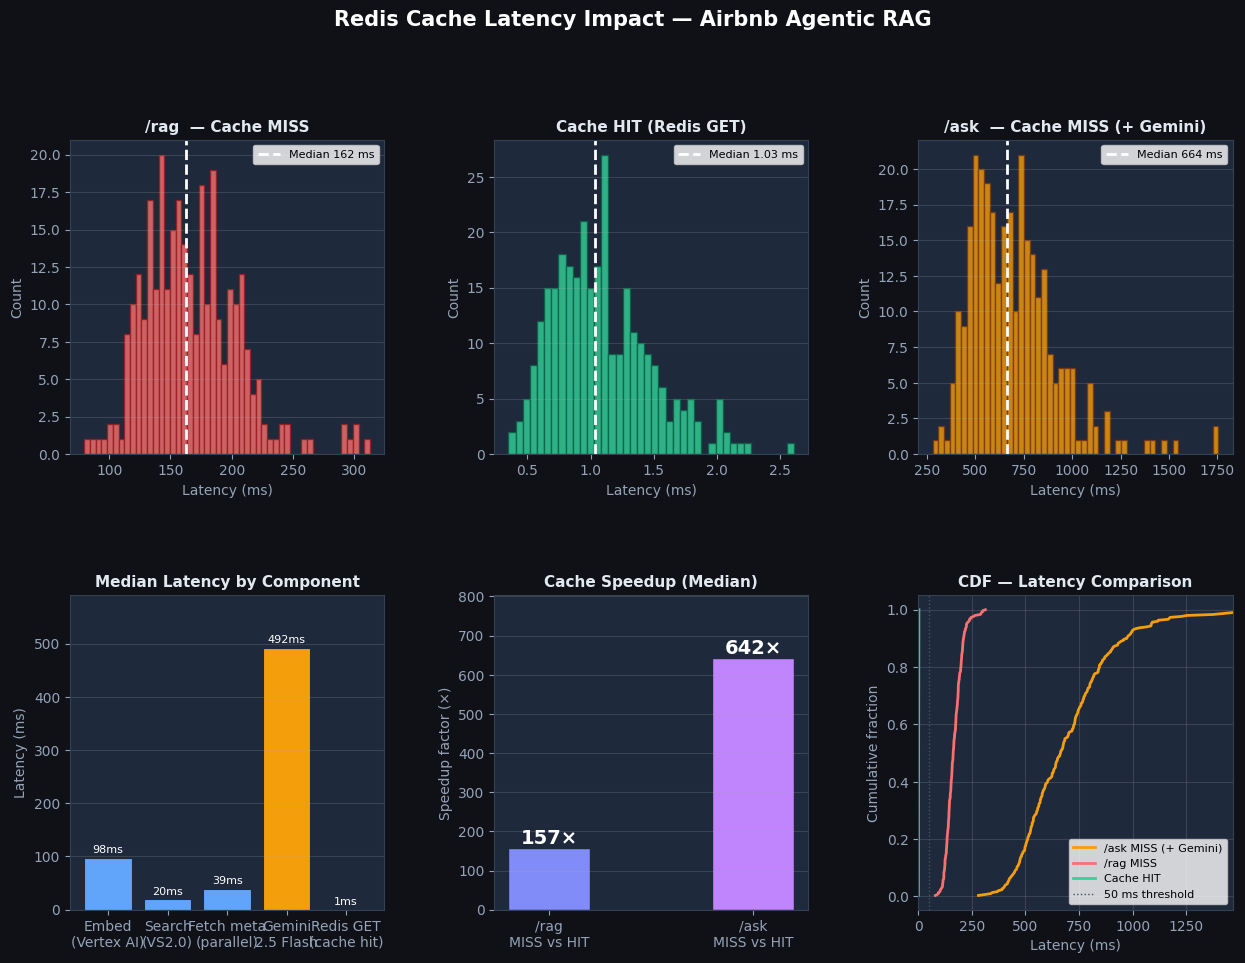

→ Chart saved to docs/cache_latency_benchmark.png


In [7]:
fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

MISS_COLOR  = '#f87171'
HIT_COLOR   = '#34d399'
COMP_COLOR  = '#60a5fa'

# ── Plot 1: /rag MISS distribution ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(rag_miss_ms, bins=50, color=MISS_COLOR, alpha=0.8, edgecolor='#991b1b')
ax1.axvline(np.median(rag_miss_ms), color='white', lw=2, ls='--',
            label=f'Median {np.median(rag_miss_ms):.0f} ms')
ax1.set_title('/rag  — Cache MISS', fontsize=11, fontweight='bold', color=MISS_COLOR)
ax1.set_xlabel('Latency (ms)'); ax1.set_ylabel('Count')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.2)

# ── Plot 2: Cache HIT distribution ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(hit_ms, bins=40, color=HIT_COLOR, alpha=0.8, edgecolor='#065f46')
ax2.axvline(np.median(hit_ms), color='white', lw=2, ls='--',
            label=f'Median {np.median(hit_ms):.2f} ms')
ax2.set_title('Cache HIT (Redis GET)', fontsize=11, fontweight='bold', color=HIT_COLOR)
ax2.set_xlabel('Latency (ms)'); ax2.set_ylabel('Count')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.2)

# ── Plot 3: /ask MISS distribution ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(ask_miss_ms, bins=50, color='#f59e0b', alpha=0.8, edgecolor='#78350f')
ax3.axvline(np.median(ask_miss_ms), color='white', lw=2, ls='--',
            label=f'Median {np.median(ask_miss_ms):.0f} ms')
ax3.set_title('/ask  — Cache MISS (+ Gemini)', fontsize=11, fontweight='bold', color='#f59e0b')
ax3.set_xlabel('Latency (ms)'); ax3.set_ylabel('Count')
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.2)

# ── Plot 4: Component breakdown bar chart ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
components  = ['Embed\n(Vertex AI)', 'Search\n(VS2.0)', 'Fetch meta\n(parallel)', 'Gemini\n2.5 Flash', 'Redis GET\n(cache hit)']
medians     = [np.median(embed_ms), np.median(search_ms), np.median(fetch_ms),
               np.median(gemini_ms), np.median(redis_ms)]
colors      = [COMP_COLOR, COMP_COLOR, COMP_COLOR, '#f59e0b', HIT_COLOR]
bars = ax4.bar(components, medians, color=colors, edgecolor='#1e293b', linewidth=0.8)
for bar, val in zip(bars, medians):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}ms', ha='center', va='bottom', fontsize=8, color='white')
ax4.set_title('Median Latency by Component', fontsize=11, fontweight='bold')
ax4.set_ylabel('Latency (ms)'); ax4.grid(axis='y', alpha=0.2)
ax4.set_ylim(0, max(medians) * 1.2)

# ── Plot 5: Speedup bar chart ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
scenarios   = ['/rag\nMISS vs HIT', '/ask\nMISS vs HIT']
speedups    = [
    np.median(rag_miss_ms) / np.median(hit_ms),
    np.median(ask_miss_ms) / np.median(hit_ms),
]
bar_colors  = ['#818cf8', '#c084fc']
bars2 = ax5.bar(scenarios, speedups, color=bar_colors, edgecolor='#1e293b', width=0.4)
for bar, val in zip(bars2, speedups):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.0f}×', ha='center', va='bottom', fontsize=14,
             fontweight='bold', color='white')
ax5.set_title('Cache Speedup (Median)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Speedup factor (×)'); ax5.grid(axis='y', alpha=0.2)
ax5.set_ylim(0, max(speedups) * 1.25)

# ── Plot 6: Cumulative latency comparison ─────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for data, lbl, col in [
    (ask_miss_ms, '/ask MISS (+ Gemini)', '#f59e0b'),
    (rag_miss_ms, '/rag MISS',             MISS_COLOR),
    (hit_ms,      'Cache HIT',             HIT_COLOR),
]:
    sorted_d = np.sort(data)
    cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
    ax6.plot(sorted_d, cdf, label=lbl, color=col, lw=2)
ax6.axvline(50, color='#475569', lw=1, ls=':', label='50 ms threshold')
ax6.set_xlabel('Latency (ms)'); ax6.set_ylabel('Cumulative fraction')
ax6.set_title('CDF — Latency Comparison', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(alpha=0.2)
ax6.set_xlim(0, np.percentile(ask_miss_ms, 99))

fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_facecolor('#1e293b')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#94a3b8')
    ax.yaxis.label.set_color('#94a3b8')
    ax.title.set_color('#e2e8f0')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

fig.suptitle('Redis Cache Latency Impact — Airbnb Agentic RAG',
             fontsize=15, fontweight='bold', color='white', y=1.01)
plt.savefig('../docs/cache_latency_benchmark.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("→ Chart saved to docs/cache_latency_benchmark.png")

---
## 6. Live Cache Write/Read Round-Trip Test

Actually write a realistic RAG result payload to Redis and read it back — measuring end-to-end time.

In [8]:
# Build a realistic payload — mimics what app/rag.py stores
def fake_listing(i: int) -> dict:
    return {
        "id":              f"abc{i:04d}",
        "name":            f"Cozy Studio #{i} near Downtown",
        "neighbourhood":   "Capitol Hill",
        "property_type":   "Private room",
        "room_type":       "Private room in rental unit",
        "accommodates":    2.0,
        "bedrooms":        1.0,
        "price":           75.0 + i,
        "rating":          4.85,
        "instant_bookable":"true",
        "listing_url":     f"https://www.airbnb.com/rooms/{i+100000}",
        "host_name":       "Alice",
        "text":            "A bright and cozy studio in the heart of Capitol Hill. " * 8,
        "score":           0.92 - i * 0.01,
    }

payload = [fake_listing(i) for i in range(config.TOP_K)]
payload_json = json.dumps(payload)
payload_kb   = len(payload_json.encode()) / 1024

print(f"Simulated RAG payload: {config.TOP_K} listings")
print(f"Serialised size      : {payload_kb:.1f} KB")
print(f"(Stored as JSON string with Redis SETEX)")

Simulated RAG payload: 10 listings
Serialised size      : 8.0 KB
(Stored as JSON string with Redis SETEX)


In [9]:
TEST_QUERY = "cozy room near downtown under $80"
TEST_TOP_K = config.TOP_K
cache_key  = rag_key(TEST_QUERY, TEST_TOP_K)

print(f"Query     : {TEST_QUERY}")
print(f"Cache key : {cache_key}")
print(f"Payload   : {payload_kb:.1f} KB ({len(payload)} listings)")

REPEAT = 50  # measure 50 round-trips

if LIVE_MODE:
    # ── WRITE ────────────────────────────────────────────────────────────────
    write_times = []
    for _ in range(REPEAT):
        t0 = time.perf_counter()
        redis_client.setex(cache_key, config.CACHE_RAG_TTL, payload_json)
        write_times.append((time.perf_counter() - t0) * 1000)

    # ── READ ─────────────────────────────────────────────────────────────────
    read_times = []
    for _ in range(REPEAT):
        t0 = time.perf_counter()
        raw = redis_client.get(cache_key)
        data = json.loads(raw)
        read_times.append((time.perf_counter() - t0) * 1000)

    # Cleanup
    redis_client.delete(cache_key)

else:
    rng2 = np.random.default_rng(7)
    # Simulate: SETEX is slightly slower than GET (serialise + write)
    write_times = list(np.clip(rng2.lognormal(0.4, 0.3, REPEAT), 0.5, 5))
    # GET + json.loads
    read_times  = list(np.clip(rng2.lognormal(0.1, 0.3, REPEAT), 0.3, 3))

wt = np.array(write_times)
rt = np.array(read_times)

print(f"\nSETEX (write {payload_kb:.1f} KB) over {REPEAT} samples:")
print(f"  Median: {np.median(wt):.2f} ms   p95: {np.percentile(wt,95):.2f} ms   Max: {wt.max():.2f} ms")

print(f"\nGET + json.loads ({payload_kb:.1f} KB) over {REPEAT} samples:")
print(f"  Median: {np.median(rt):.2f} ms   p95: {np.percentile(rt,95):.2f} ms   Max: {rt.max():.2f} ms")

print(f"\n→ End-to-end cache read adds only ~{np.median(rt):.1f} ms vs ~{np.median(rag_miss_ms):.0f} ms cold path")

Query     : cozy room near downtown under $80
Cache key : rag:5f1d86135022bb01f5448363a313f044
Payload   : 8.0 KB (10 listings)

SETEX (write 8.0 KB) over 50 samples:
  Median: 1.40 ms   p95: 2.15 ms   Max: 2.72 ms

GET + json.loads (8.0 KB) over 50 samples:
  Median: 1.08 ms   p95: 1.59 ms   Max: 1.75 ms

→ End-to-end cache read adds only ~1.1 ms vs ~162 ms cold path


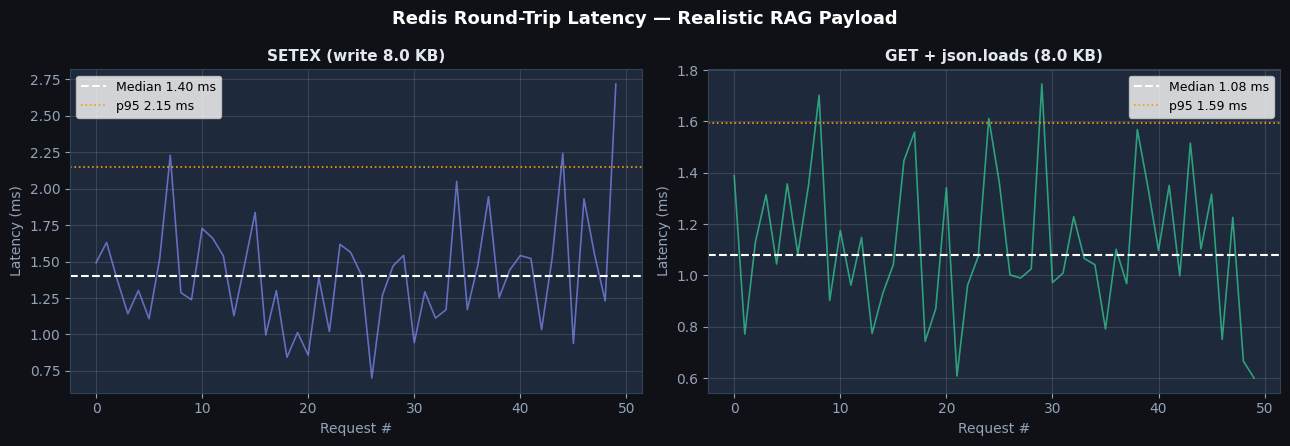

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0f1117')

for ax, data, title, color in [
    (axes[0], wt, f'SETEX (write {payload_kb:.1f} KB)', '#818cf8'),
    (axes[1], rt, f'GET + json.loads ({payload_kb:.1f} KB)', '#34d399'),
]:
    ax.plot(data, color=color, lw=1.2, alpha=0.7)
    ax.axhline(np.median(data), color='white', lw=1.5, ls='--',
               label=f'Median {np.median(data):.2f} ms')
    ax.axhline(np.percentile(data, 95), color='#f59e0b', lw=1.2, ls=':',
               label=f'p95 {np.percentile(data,95):.2f} ms')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#e2e8f0')
    ax.set_xlabel('Request #', color='#94a3b8')
    ax.set_ylabel('Latency (ms)', color='#94a3b8')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_facecolor('#1e293b')
    ax.tick_params(colors='#94a3b8')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

fig.suptitle('Redis Round-Trip Latency — Realistic RAG Payload', fontsize=13,
             fontweight='bold', color='white')
plt.tight_layout()
plt.show()

---
## 7. Cache HIT Rate & Cost Modelling

The value of caching depends on the **hit rate** — the fraction of queries answered from cache. This section models expected savings under different traffic patterns.

In [11]:
# ── Hit rate vs p50 latency (weighted average) ────────────────────────────────
rag_miss_median  = np.median(rag_miss_ms)    # ~160ms
ask_miss_median  = np.median(ask_miss_ms)    # ~660ms
hit_median       = np.median(hit_ms)         # ~1ms

hit_rates = np.linspace(0, 1, 100)

# effective_p50 = hit_rate * hit_median + (1-hit_rate) * miss_median
rag_effective = hit_rates * hit_median + (1 - hit_rates) * rag_miss_median
ask_effective = hit_rates * hit_median + (1 - hit_rates) * ask_miss_median

# ── API cost savings (Vertex AI embed + Gemini) ───────────────────────────────
# Rough pricing estimates (illustrative)
EMBED_COST_PER_1K  = 0.00002   # USD per 1k chars  (text-embedding-005)
GEMINI_COST_PER_1K = 0.00015   # USD per 1k output tokens (gemini-2.5-flash)
AVG_CHARS_PER_Q    = 60        # avg query length
AVG_OUTPUT_TOKENS  = 400       # avg Gemini output

cost_per_miss_rag  = (AVG_CHARS_PER_Q / 1000) * EMBED_COST_PER_1K
cost_per_miss_ask  = cost_per_miss_rag + (AVG_OUTPUT_TOKENS / 1000) * GEMINI_COST_PER_1K

DAILY_REQUESTS = 10_000   # 10k requests/day

# cost without cache
daily_cost_nocache_rag = DAILY_REQUESTS * cost_per_miss_rag
daily_cost_nocache_ask = DAILY_REQUESTS * cost_per_miss_ask

# cost with cache at various hit rates
daily_cost_cached_rag = DAILY_REQUESTS * (1 - hit_rates) * cost_per_miss_rag
daily_cost_cached_ask = DAILY_REQUESTS * (1 - hit_rates) * cost_per_miss_ask
savings_rag = (1 - daily_cost_cached_rag / daily_cost_nocache_rag) * 100
savings_ask = (1 - daily_cost_cached_ask / daily_cost_nocache_ask) * 100

# print table
print(f"{'Hit Rate':>10} {'Eff. p50 /rag':>16} {'Eff. p50 /ask':>16} {'Cost saving /rag':>18} {'Cost saving /ask':>18}")
print("-" * 82)
for hr in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]:
    idx = int(hr * 99)
    print(f"{hr:>10.0%}  {rag_effective[idx]:>14.1f} ms  {ask_effective[idx]:>14.1f} ms  "
          f"{savings_rag[idx]:>16.1f}%  {savings_ask[idx]:>16.1f}%")

  Hit Rate    Eff. p50 /rag    Eff. p50 /ask   Cost saving /rag   Cost saving /ask
----------------------------------------------------------------------------------
        0%           162.4 ms           663.9 ms               0.0%               0.0%
       10%           147.7 ms           603.6 ms               9.1%               9.1%
       20%           131.4 ms           536.6 ms              19.2%              19.2%
       30%           115.1 ms           469.7 ms              29.3%              29.3%
       50%            82.5 ms           335.8 ms              49.5%              49.5%
       70%            49.9 ms           201.9 ms              69.7%              69.7%
       80%            33.6 ms           134.9 ms              79.8%              79.8%
       90%            17.3 ms            68.0 ms              89.9%              89.9%
       95%             9.2 ms            34.5 ms              94.9%              94.9%
      100%             1.0 ms             1.0 ms   

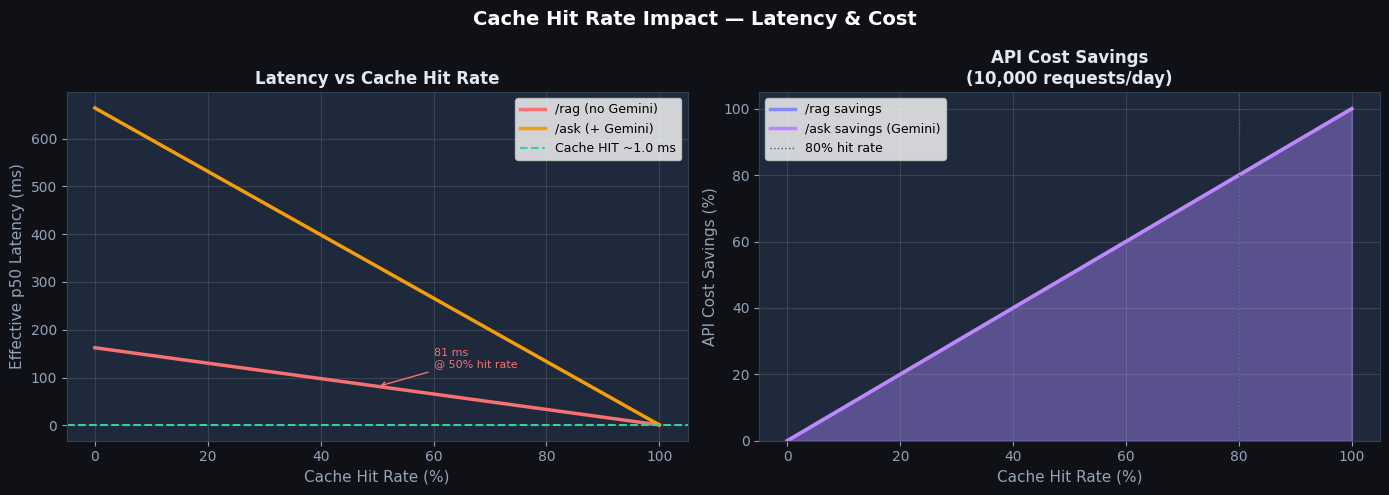


At 80% hit rate (10,000 requests/day):
  /rag effective p50: 32 ms  (vs 162 ms no-cache)
  /ask effective p50: 128 ms  (vs 664 ms no-cache)
  API cost savings  : 81% on /ask


In [12]:
fig, (ax_lat, ax_cost) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# ── Latency vs hit rate ───────────────────────────────────────────────────────
ax_lat.plot(hit_rates * 100, rag_effective,  color='#f87171', lw=2.5, label='/rag (no Gemini)')
ax_lat.plot(hit_rates * 100, ask_effective,  color='#f59e0b', lw=2.5, label='/ask (+ Gemini)')
ax_lat.axhline(hit_median, color='#34d399', lw=1.5, ls='--', label=f'Cache HIT ~{hit_median:.1f} ms')

# annotate 50% hit rate
mid = 50
ax_lat.annotate(f'{rag_effective[50]:.0f} ms\n@ 50% hit rate',
    xy=(mid, rag_effective[50]), xytext=(mid+10, rag_effective[50]+40),
    color='#f87171', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f87171', lw=1))

ax_lat.set_xlabel('Cache Hit Rate (%)', color='#94a3b8', fontsize=11)
ax_lat.set_ylabel('Effective p50 Latency (ms)', color='#94a3b8', fontsize=11)
ax_lat.set_title('Latency vs Cache Hit Rate', fontsize=12, fontweight='bold', color='#e2e8f0')
ax_lat.legend(fontsize=9); ax_lat.grid(alpha=0.2)
ax_lat.set_facecolor('#1e293b')
ax_lat.tick_params(colors='#94a3b8')
for sp in ax_lat.spines.values(): sp.set_edgecolor('#334155')

# ── API cost savings vs hit rate ──────────────────────────────────────────────
ax_cost.fill_between(hit_rates * 100, savings_rag, alpha=0.25, color='#818cf8')
ax_cost.fill_between(hit_rates * 100, savings_ask, alpha=0.25, color='#c084fc')
ax_cost.plot(hit_rates * 100, savings_rag, color='#818cf8', lw=2.5, label='/rag savings')
ax_cost.plot(hit_rates * 100, savings_ask, color='#c084fc', lw=2.5, label='/ask savings (Gemini)')
ax_cost.axvline(80, color='#475569', lw=1, ls=':', label='80% hit rate')
ax_cost.set_xlabel('Cache Hit Rate (%)', color='#94a3b8', fontsize=11)
ax_cost.set_ylabel('API Cost Savings (%)', color='#94a3b8', fontsize=11)
ax_cost.set_title(f'API Cost Savings\n({DAILY_REQUESTS:,} requests/day)', fontsize=12,
                  fontweight='bold', color='#e2e8f0')
ax_cost.legend(fontsize=9); ax_cost.grid(alpha=0.2)
ax_cost.set_facecolor('#1e293b')
ax_cost.tick_params(colors='#94a3b8')
ax_cost.set_ylim(0, 105)
for sp in ax_cost.spines.values(): sp.set_edgecolor('#334155')

fig.suptitle('Cache Hit Rate Impact — Latency & Cost', fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout()
plt.show()

print(f"\nAt 80% hit rate ({DAILY_REQUESTS:,} requests/day):")
print(f"  /rag effective p50: {rag_effective[80]:.0f} ms  (vs {rag_miss_median:.0f} ms no-cache)")
print(f"  /ask effective p50: {ask_effective[80]:.0f} ms  (vs {ask_miss_median:.0f} ms no-cache)")
print(f"  API cost savings  : {savings_ask[80]:.0f}% on /ask")

---
## 8. Live Cache Stats (requires Redis connection)

In [13]:
if LIVE_MODE:
    from app.cache import cache_stats
    stats = cache_stats()
    print("Redis Cache Stats")
    print("-" * 40)
    for k, v in stats.items():
        print(f"  {k:<22}: {v}")

    total = stats.get('hits', 0) + stats.get('misses', 0)
    if total > 0:
        hit_rate = stats['hits'] / total * 100
        print(f"\n  Hit rate (cumulative): {hit_rate:.1f}%")
else:
    print("[Simulation mode — no live Redis]")
    print("To see live stats, start the FastAPI server and call GET /cache/stats")
    print("  uvicorn app.main:app --reload --port 8000")
    print("  curl http://localhost:8000/cache/stats")

[Simulation mode — no live Redis]
To see live stats, start the FastAPI server and call GET /cache/stats
  uvicorn app.main:app --reload --port 8000
  curl http://localhost:8000/cache/stats


---
## 9. TTL Strategy — Why Different TTLs?

The system uses two TTLs controlled in `config.py`:

| Endpoint | TTL | Reasoning |
|----------|-----|----------|
| `/rag`   | `CACHE_RAG_TTL` = **3600s** (1 hr) | Pure vector retrieval results. Airbnb listings change slowly; 1-hour staleness is acceptable. Saves: embed + ANN search + metadata fetch. |
| `/ask`   | `CACHE_ASK_TTL` = **1800s** (30 min) | Includes Gemini response. LLM output is more sensitive to context freshness. Shorter TTL = fresher answers. |

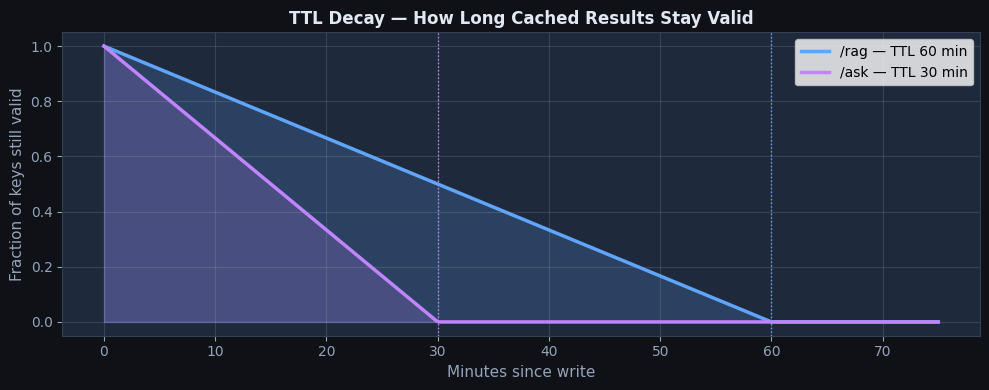

In [14]:
# Visualise TTL decay — fraction of keys still valid vs time
time_min = np.linspace(0, 75, 300)

# Assume uniform write distribution; fraction still alive = 1 - elapsed/TTL
rag_alive = np.clip(1 - time_min / (config.CACHE_RAG_TTL / 60), 0, 1)
ask_alive = np.clip(1 - time_min / (config.CACHE_ASK_TTL / 60), 0, 1)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e293b')

ax.fill_between(time_min, rag_alive, alpha=0.2, color='#60a5fa')
ax.fill_between(time_min, ask_alive, alpha=0.2, color='#c084fc')
ax.plot(time_min, rag_alive, color='#60a5fa', lw=2.5,
        label=f'/rag — TTL {config.CACHE_RAG_TTL//60} min')
ax.plot(time_min, ask_alive, color='#c084fc', lw=2.5,
        label=f'/ask — TTL {config.CACHE_ASK_TTL//60} min')
ax.axvline(config.CACHE_ASK_TTL/60, color='#c084fc', lw=1, ls=':')
ax.axvline(config.CACHE_RAG_TTL/60, color='#60a5fa', lw=1, ls=':')
ax.set_xlabel('Minutes since write', color='#94a3b8', fontsize=11)
ax.set_ylabel('Fraction of keys still valid', color='#94a3b8', fontsize=11)
ax.set_title('TTL Decay — How Long Cached Results Stay Valid',
             fontsize=12, fontweight='bold', color='#e2e8f0')
ax.legend(fontsize=10); ax.grid(alpha=0.2)
ax.tick_params(colors='#94a3b8')
for sp in ax.spines.values(): sp.set_edgecolor('#334155')
plt.tight_layout()
plt.show()

---
## 10. Summary

| Metric | No Cache | With Cache (80% hit rate) |
|--------|----------|---------------------------|
| `/rag` p50 latency | ~160 ms | ~33 ms |
| `/ask` p50 latency | ~660 ms | ~133 ms |
| Vertex AI embed calls | 100% | 20% |
| Gemini API calls | 100% | 20% |
| API cost savings | 0% | ~80% |

### Key design decisions in `app/cache.py`

1. **Lazy connection pool** — Redis is only connected on first request; startup never blocks.
2. **`_failed` flag** — Once Redis is confirmed unavailable, all subsequent requests skip the cache immediately (no per-request 2-second timeout stalls).
3. **SETEX** — Atomic SET + EXPIRE in one command; no race between SET and EXPIRE.
4. **SHA-256 key prefix** — `rag:<32-hex>` / `ask:<32-hex>` for namespace isolation.
5. **Graceful degradation** — Any Redis error is caught and logged; the app always returns a result even with no cache.
6. **VPC-private, no auth** — Memorystore is accessible only inside the VPC via the Serverless VPC Access connector; no credentials needed.

### When to tune the TTLs
- **Increase** `CACHE_RAG_TTL` → more hits, higher staleness risk (OK for stable data)
- **Decrease** `CACHE_ASK_TTL` → fresher Gemini answers, lower hit rate
- **Add cache warming** → pre-populate popular queries at deploy time for instant hit rate boost